# TASK 1 - Sales Data Analysis

## Objective
Analyze sales data from a CSV file using Python and Pandas to extract key business insights.

### Tools Used
- Python
- Pandas
- Matplotlib
- Seaborn

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Set visualization style
sns.set_style("whitegrid")

print("Libraries imported successfully!")

Libraries imported successfully!


In [ ]:
from google.colab import files

uploaded = files.upload()
df = pd.read_csv(
    "sales_data_sample.csv",
    encoding="ISO-8859-1"
)
print("Dataset loaded successfully!")

Saving sales_data_sample.csv to sales_data_sample.csv
Dataset loaded successfully!


In [ ]:
df.head()

,ORDERNUMBER,QUANTITYORDERED,PRICEEACH,ORDERLINENUMBER,SALES,ORDERDATE,STATUS,QTR_ID,MONTH_ID,YEAR_ID,...,ADDRESSLINE1,ADDRESSLINE2,CITY,STATE,POSTALCODE,COUNTRY,TERRITORY,CONTACTLASTNAME,CONTACTFIRSTNAME,DEALSIZE
0,10107,30,95.70,2,2871.00,2/24/2003 0:00,Shipped,1,2,2003,...,897 Long Airport Avenue,NaN,NYC,NY,10022,USA,NaN,Yu,Kwai,Small
1,10121,34,81.35,5,2765.90,5/7/2003 0:00,Shipped,2,5,2003,...,59 rue de l'Abbaye,NaN,Reims,NaN,51100,France,EMEA,Henriot,Paul,Small
2,10134,41,94.74,2,3884.34,7/1/2003 0:00,Shipped,3,7,2003,...,27 rue du Colonel Pierre Avia,NaN,Paris,NaN,75508,France,EMEA,Da Cunha,Daniel,Medium
3,10145,45,83.26,6,3746.70,8/25/2003 0:00,Shipped,3,8,2003,...,78934 Hillside Dr.,NaN,Pasadena,CA,90003,USA,NaN,Young,Julie,Medium
4,10159,49,100.00,14,5205.27,10/10/2003 0:00,Shipped,4,10,2003,...,7734 Strong St.,NaN,San Francisco,CA,NaN,USA,NaN,Brown,Julie,Medium


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2823 entries, 0 to 2822
Data columns (total 25 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   ORDERNUMBER       2823 non-null   int64  
 1   QUANTITYORDERED   2823 non-null   int64  
 2   PRICEEACH         2823 non-null   float64
 3   ORDERLINENUMBER   2823 non-null   int64  
 4   SALES             2823 non-null   float64
 5   ORDERDATE         2823 non-null   object 
 6   STATUS            2823 non-null   object 
 7   QTR_ID            2823 non-null   int64  
 8   MONTH_ID          2823 non-null   int64  
 9   YEAR_ID           2823 non-null   int64  
 10  PRODUCTLINE       2823 non-null   object 
 11  MSRP              2823 non-null   int64  
 12  PRODUCTCODE       2823 non-null   object 
 13  CUSTOMERNAME      2823 non-null   object 
 14  PHONE             2823 non-null   object 
 15  ADDRESSLINE1      2823 non-null   object 
 16  ADDRESSLINE2      302 non-null    object 


# **Basic statistics**

In [ ]:
total_sales = df["SALES"].sum()
average_sales = df["SALES"].mean()
maximum_sales = df["SALES"].max()
minimum_sales = df["SALES"].min()

print("Sales Statistics")
print("-" * 30)
print(f"Total Sales   : ${total_sales:,.2f}")
print(f"Average Sales : ${average_sales:,.2f}")
print(f"Maximum Sales : ${maximum_sales:,.2f}")
print(f"Minimum Sales : ${minimum_sales:,.2f}")

Sales Statistics
------------------------------
Total Sales   : $10,032,628.85
Average Sales : $3,553.89
Maximum Sales : $14,082.80
Minimum Sales : $482.13


In [ ]:
category_sales = (
    df.groupby("PRODUCTLINE")["SALES"]
    .sum()
    .sort_values(ascending=False)
)

category_sales

,SALES
PRODUCTLINE,
Classic Cars,3919615.66
Vintage Cars,1903150.84
Motorcycles,1166388.34
Trucks and Buses,1127789.84
Planes,975003.57
Ships,714437.13
Trains,226243.47


In [ ]:
top_categories = category_sales.head(5)

print("Top 5 Product Categories by Sales:")
print(top_categories)

Top 5 Product Categories by Sales:
PRODUCTLINE
Classic Cars        3919615.66
Vintage Cars        1903150.84
Motorcycles         1166388.34
Trucks and Buses    1127789.84
Planes               975003.57
Name: SALES, dtype: float64


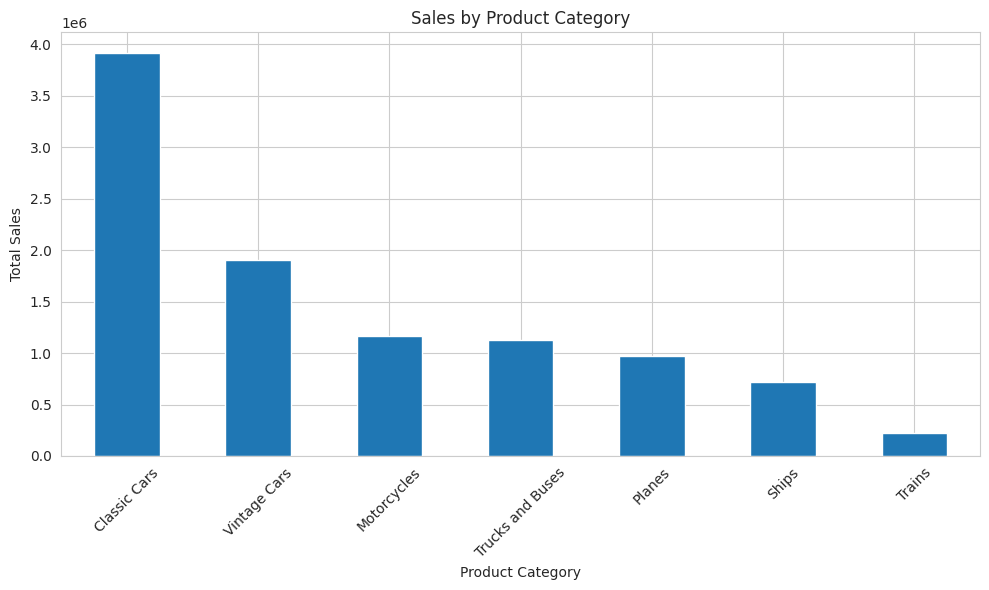

In [ ]:
plt.figure(figsize=(10, 6))

category_sales.plot(kind="bar")

plt.title("Sales by Product Category")
plt.xlabel("Product Category")
plt.ylabel("Total Sales")
plt.xticks(rotation=45)
plt.tight_layout()

plt.show()

In [ ]:
country_sales = (
    df.groupby("COUNTRY")["SALES"]
    .sum()
    .sort_values(ascending=False)
)

country_sales.head(10)

,SALES
COUNTRY,
USA,3627982.83
Spain,1215686.92
France,1110916.52
Australia,630623.10
UK,478880.46
Italy,374674.31
Finland,329581.91
Norway,307463.70
Singapore,288488.41


In [ ]:
top_countries = country_sales.head(10)

print("Top 10 Countries by Sales:")
print(top_countries)

Top 10 Countries by Sales:
COUNTRY
USA          3627982.83
Spain        1215686.92
France       1110916.52
Australia     630623.10
UK            478880.46
Italy         374674.31
Finland       329581.91
Norway        307463.70
Singapore     288488.41
Denmark       245637.15
Name: SALES, dtype: float64


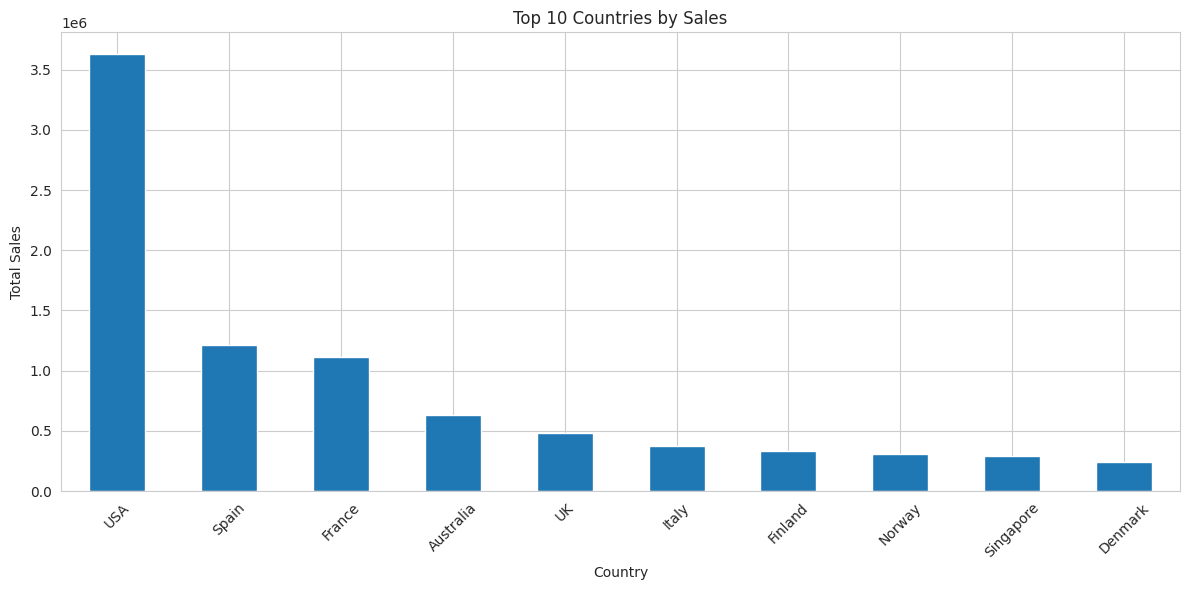

In [ ]:
plt.figure(figsize=(12, 6))

top_countries.plot(kind="bar")

plt.title("Top 10 Countries by Sales")
plt.xlabel("Country")
plt.ylabel("Total Sales")
plt.xticks(rotation=45)
plt.tight_layout()

plt.show()

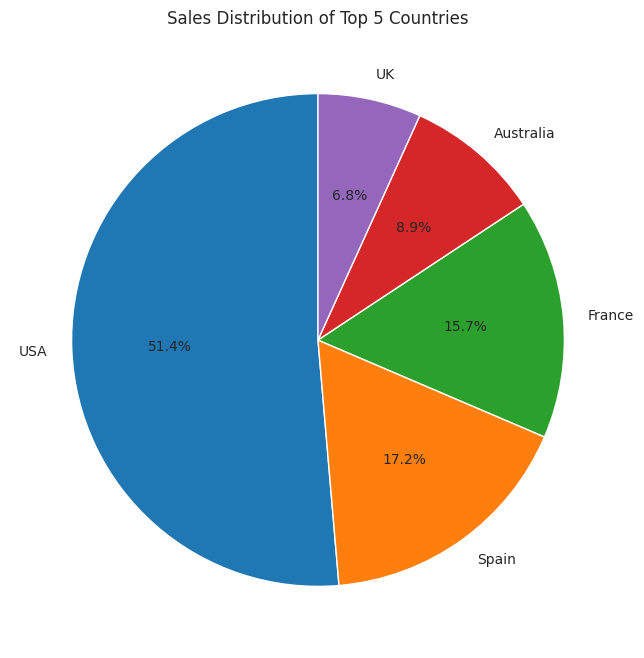

In [ ]:
top_5_countries = country_sales.head(5)

plt.figure(figsize=(8, 8))

plt.pie(
    top_5_countries,
    labels=top_5_countries.index,
    autopct="%1.1f%%",
    startangle=90
)

plt.title("Sales Distribution of Top 5 Countries")

plt.show()

In [ ]:
product_sales = (
    df.groupby("PRODUCTCODE")["SALES"]
    .sum()
    .sort_values(ascending=False)
)

product_sales.head(10)

,SALES
PRODUCTCODE,
S18_3232,288245.42
S10_1949,191073.03
S10_4698,170401.07
S12_1108,168585.32
S18_2238,154623.95
S12_3891,145332.04
S24_3856,140626.90
S12_2823,140006.16
S18_1662,139421.97


In [ ]:
top_products = product_sales.head(10)

print("Top 10 Products by Sales:")
print(top_products)

Top 10 Products by Sales:
PRODUCTCODE
S18_3232    288245.42
S10_1949    191073.03
S10_4698    170401.07
S12_1108    168585.32
S18_2238    154623.95
S12_3891    145332.04
S24_3856    140626.90
S12_2823    140006.16
S18_1662    139421.97
S12_1099    137177.01
Name: SALES, dtype: float64


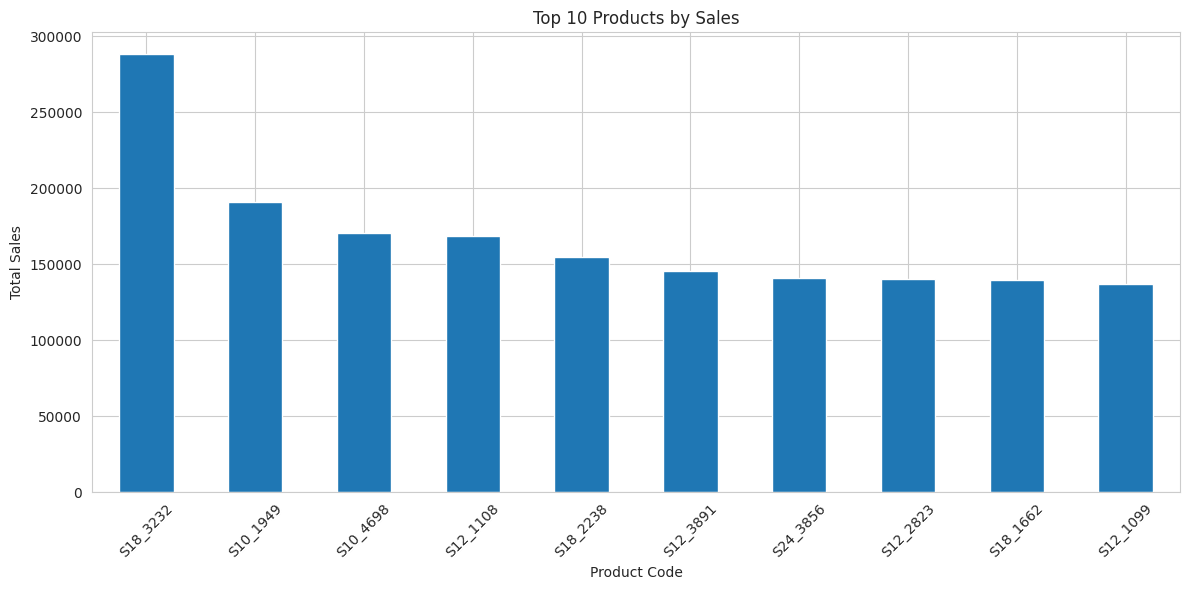

In [ ]:
plt.figure(figsize=(12, 6))

top_products.plot(kind="bar")

plt.title("Top 10 Products by Sales")
plt.xlabel("Product Code")
plt.ylabel("Total Sales")
plt.xticks(rotation=45)
plt.tight_layout()

plt.show()